# DynaMix benchmarks


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
# sys.path.append('.')
sys.path.append('./DynaMix/')

plt.rcParams["font.family"] = "Helvetica"

from src.model.dynamix import DynaMix
from src.model.forecaster import DynaMixForecaster
from src.metrics.metrics import geometrical_misalignment, temporal_misalignment, MASE
from src.utilities.plotting_eval import plot_3D_attractor, plot_2D_attractor, plot_TS_forecast
from src.utilities.utilities import load_hf_model

In [2]:
from dysts.metrics import smape


def vpt_smape(x, xhat, threshold=30):
    """
    Find the first time index at which an array exceeds a threshold.

    Args:
        x (np.ndarray): The ground truth, a time series of shape (nt, 1).
        xhat (np.ndarray): The forecast, a time series of shape (nt, 1).
        threshold (float): The threshold to search for.

    Returns:
        int: The first time index at which the array exceeds the threshold.
    """
    arr = horizoned_smape(x, xhat)
    exceed_times = np.where(arr > threshold)[0]
    if len(exceed_times) == 0:
        tind = len(arr)
    else:
        tind = exceed_times[0]
    return tind

def horizoned_smape(x, xhat):
    """Given a horizoned forecast and ground truth, compute the SMAPE as a function of time"""
    nt = min(x.shape[0], xhat.shape[0])
    smape_vals = list()
    for i in range(1, nt+1):
        smape_vals.append(smape(x[:i], xhat[:i]))
    smape_vals = np.array(smape_vals)
    return smape_vals


def mse(y_true, y_pred):
    
    mse = np.mean((y_true - y_pred) ** 2)
    return mse

def mse_rolling(ts1, ts2):

    n = min(ts1.shape[0], ts2.shape[0])
    all_mse = list()
    for i in range(1, n+1):
        mse_val = mse(ts1[:i], ts2[:i])
        all_mse.append(mse_val)

    return np.array(all_mse)

def mae(y_true, y_pred):
    
    mae = np.mean(np.abs(y_true - y_pred))
    return mae

def mae_rolling(ts1, ts2):

    n = min(ts1.shape[0], ts2.shape[0])
    all_mae = list()
    for i in range(1, n+1):
        mae_val = mae(ts1[:i], ts2[:i])
        all_mae.append(mae_val)

    return np.array(all_mae)

# Von Karman Street

Data shape: (2001, 23)
Parrot MSE: 0.004116574011617012, 6.48099328086043e-08
DynaMix MSE: 0.006369246255316233, 0.00027456340780643567
Parrot MAE: 0.058758780554893135, 4.6253616376652423e-07
DynaMix MAE: 0.07588753049700879, 0.0015968713204689354
average Parrot KL: 0.9257630260551896, 0.1351997860022306
average DynaMix KL: 1.0097505453807851, 0.15037243382270346


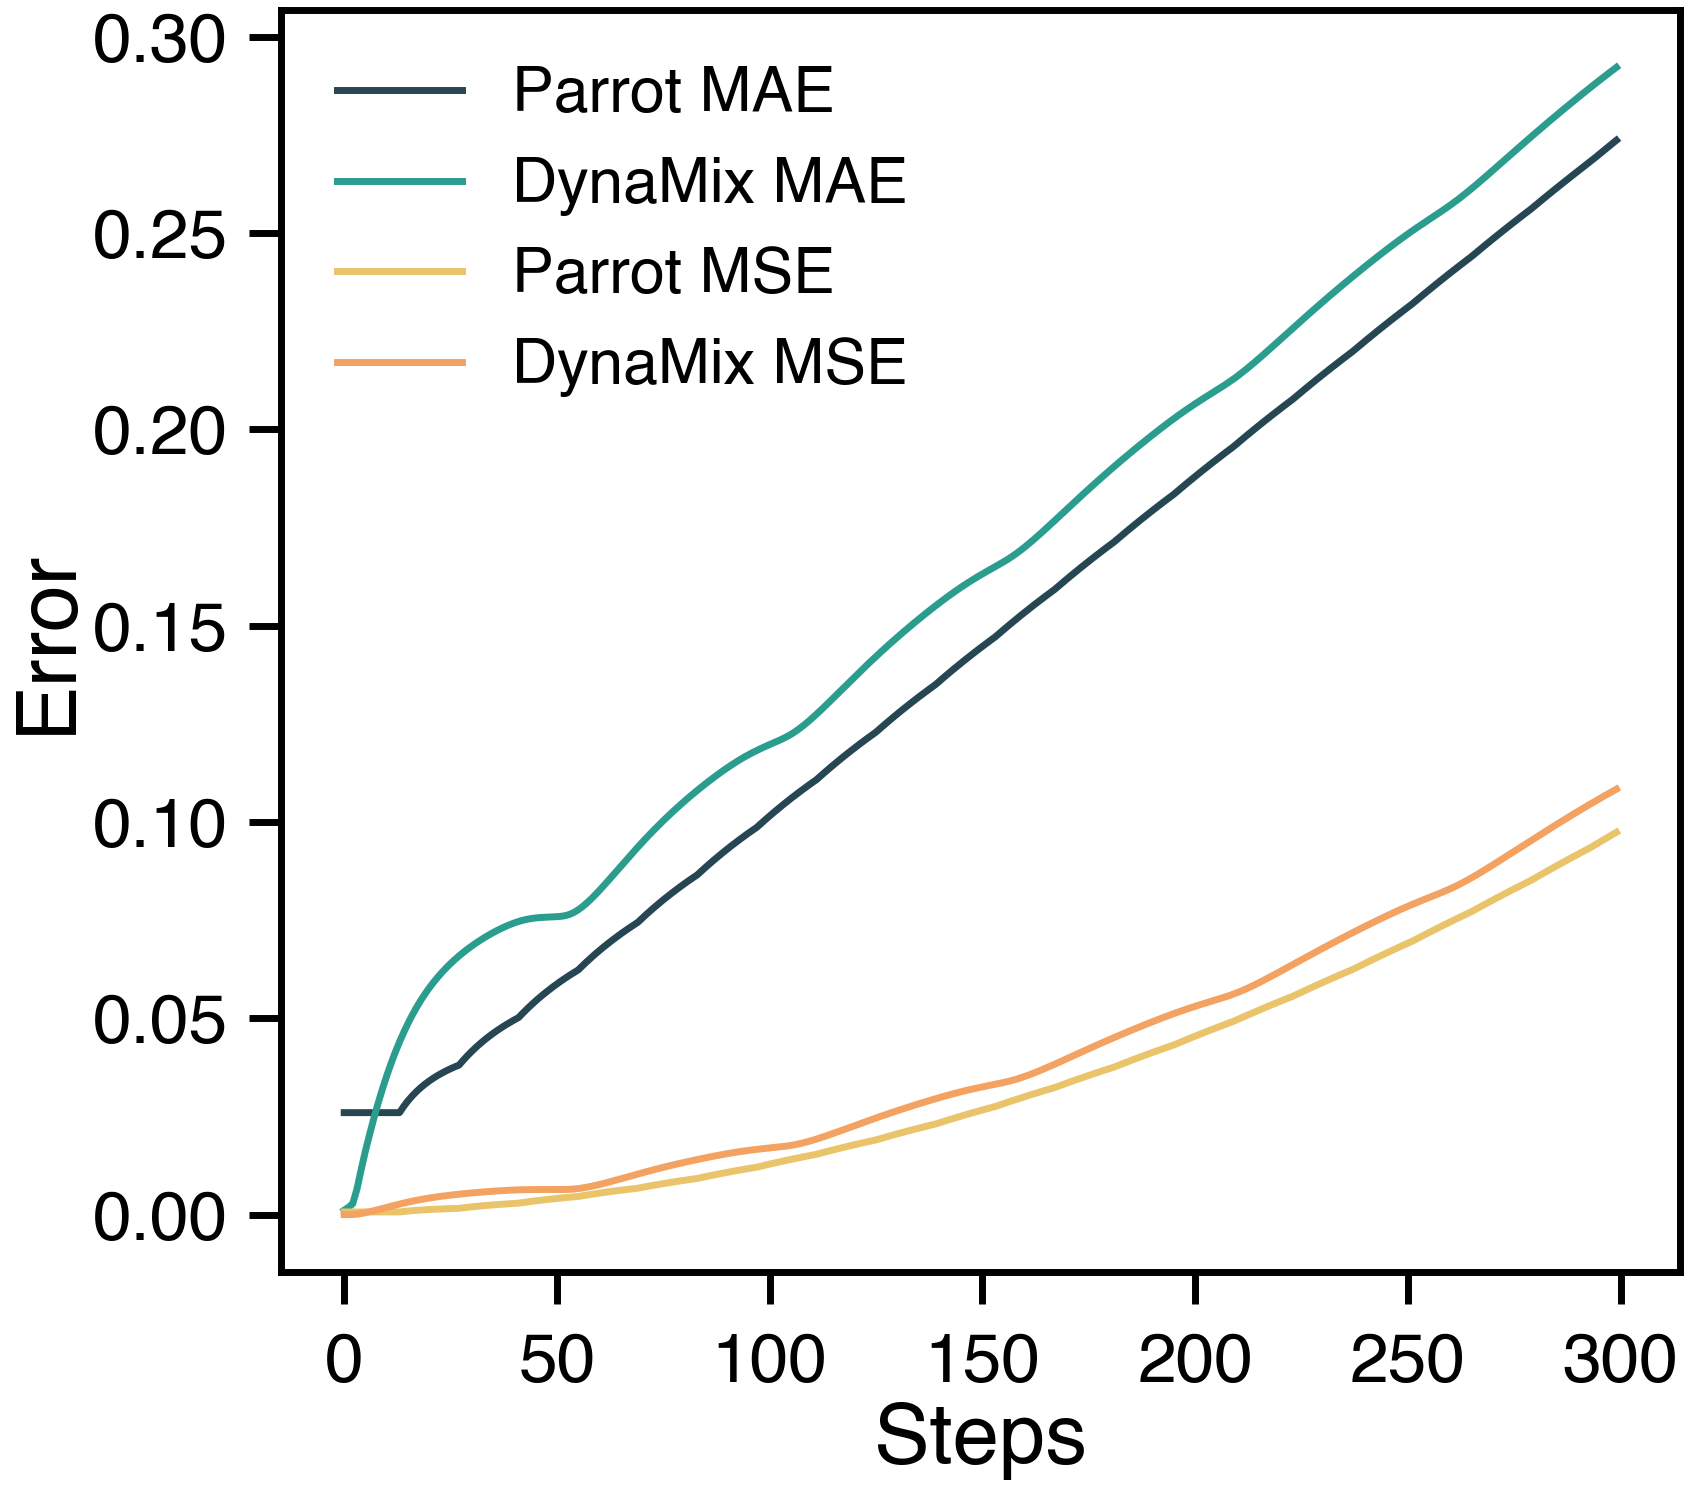

In [15]:
RE_VAL = 900 # Change this to 300, 600, 900, 1200
import random

import sys
sys.path.append('..')
from models.parrot import context_parroting_forecast
from dysts.metrics import estimate_kl_divergence

SPLIT = "train" # train or test

# fpath = f"../data/electrocardiogram/ecg_train.csv.gz"
# data = np.loadtxt(fpath, delimiter=",")
# data = data.reshape(-1, 1)
# downsamplerate = 1
# data = data[::downsamplerate,:]
# num_modes = 1
# context_length = 512
# forecast_length = 300
# num_ic = 200
# num_modes = 1


## Turbulence
# X_pca = np.load(f"../data/von_karman_street/vortex_street_vorticities_Re_{RE_VAL}_pca10.pkl", allow_pickle=True)
# downsamplerate = 2
# data = X_pca[::downsamplerate,:]
# print(data.shape)
# context_length = 512
# forecast_length = 300
# num_ic = 200



## Electronic Circuit
# fpath = "../data/electronic_circuit/R1/ST_1_1.dat"
# data = np.loadtxt(fpath)
# downsamplerate = 1
# data = data[::downsamplerate,:]
# context_length = 512
# forecast_length = 300
# num_ic = 50
# num_modes = 28



fpath = "../data/kuramoto/oscillator_glass.npy"
data = np.load(fpath)
downsamplerate = 1
data = data[::downsamplerate,:]
context_length = 512
forecast_length = 300
num_ic = 50
num_modes = 23



evaluated_steps = 50


print(f"Data shape: {data.shape}")

parrot_mse = []
parrot_mae = []
parrot_kl = []
DynaMix_mse = []
DynaMix_mae = []
DynaMix_kl = []

parrot_mse_rolling = list()
parrot_mae_rolling = list()
DynaMix_mse_rolling = list()
DynaMix_mae_rolling = list()



traj = data[:,:num_modes]
# normalize the trajectory
traj = (traj - np.mean(traj, axis=0)) / np.std(traj, axis=0)


# Load the pre-trained model
model = load_hf_model("dynamix-3d-alrnn-v1.0")
model.eval() # Set model to evaluation mode
forecaster = DynaMixForecaster(model) # Initialize the forecaster

for ic in range(num_ic):

    start = random.randint(0, data.shape[0] - context_length - forecast_length)
    traj_context = traj[start:start+context_length,:]
    traj_true = traj[start+context_length:start+context_length+forecast_length,:]

    traj_pred = np.zeros_like(traj_true)
    Parrot_pred = np.zeros_like(traj_true)

    context_traj_tensor  = torch.tensor(traj_context)
    with torch.no_grad(): 
        reconstruction = forecaster.forecast(
            context=context_traj_tensor,
            horizon=forecast_length, # Match the horizon of the ground truth
            standardize=True,
        )
    traj_pred = reconstruction.detach().numpy()

    for mode in range(num_modes):

        mse_val = mse_rolling(traj_pred[:,mode], traj_true[:,mode])
        DynaMix_mse_rolling.append(np.array(mse_val))
        DynaMix_mse.append(mse_val[evaluated_steps])
        mae_val = mae_rolling(traj_pred[:,mode], traj_true[:,mode])
        DynaMix_mae_rolling.append(np.array(mae_val))
        DynaMix_mae.append(mae_val[evaluated_steps])

        best_index, min_l2_distance, Parrot_pred_single = context_parroting_forecast(traj_context[:,mode], D=15, tau=1, forecast_total_length=forecast_length)
        Parrot_pred[:,mode] = Parrot_pred_single
        
        mse_val = mse_rolling(Parrot_pred_single, traj_true[:,mode])
        parrot_mse_rolling.append(np.array(mse_val))
        parrot_mse.append(mse_val[evaluated_steps])
        mae_val = mae_rolling(Parrot_pred_single, traj_true[:,mode])
        parrot_mae_rolling.append(np.array(mae_val))
        parrot_mae.append(mae_val[evaluated_steps])

    kl_dist = estimate_kl_divergence(traj_true, traj_pred)
    if np.isinf(kl_dist):
        kl_dist = np.nan
    DynaMix_kl.append(kl_dist)

    kl_dist = estimate_kl_divergence(traj_true, Parrot_pred)
    if np.isinf(kl_dist):
        kl_dist = np.nan
    parrot_kl.append(kl_dist)

parrot_average_mae = np.mean(parrot_mae_rolling, axis=0)
parrot_average_mse = np.mean(parrot_mse_rolling, axis=0)
DynaMix_average_mae = np.mean(DynaMix_mae_rolling, axis=0)
DynaMix_average_mse = np.mean(DynaMix_mse_rolling, axis=0)

print(f"Parrot MSE: {np.mean(parrot_mse)}, {np.std(parrot_mse)}")
print(f"DynaMix MSE: {np.mean(DynaMix_mse)}, {np.std(DynaMix_mse)}")
print(f"Parrot MAE: {np.mean(parrot_mae)}, {np.std(parrot_mae)}")
print(f"DynaMix MAE: {np.mean(DynaMix_mae)}, {np.std(DynaMix_mae)}")
print(f"average Parrot KL: {np.nanmean(parrot_kl)}, {np.nanstd(parrot_kl)}")
print(f"average DynaMix KL: {np.nanmean(DynaMix_kl)}, {np.nanstd(DynaMix_kl)}")


colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

# Plot Average VPT vs. Context Length for each equation
fig = plt.figure()
ax = fig.add_subplot(111)

for axis in ['bottom','left']:
  ax.spines[axis].set_linewidth(5)
for axis in ['top','right']:
  ax.spines[axis].set_linewidth(5)
  #ax.spines[axis].set_visible(False)

ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

fig.set_size_inches(17,15)
plt.xticks(fontsize = 50)
plt.yticks(fontsize = 50)
plt.xlabel(r'Steps', fontname="Helvetica", fontsize = 60)
plt.ylabel(r'Error', fontname="Helvetica", fontsize = 60)

plt.plot(parrot_average_mae, lw=5, ls='-', alpha=1, color=colors[0], label='Parrot MAE')
plt.plot(DynaMix_average_mae, lw=5, ls='-', alpha=1, color=colors[1], label='DynaMix MAE')
plt.plot(parrot_average_mse, lw=5, ls='-', alpha=1, color=colors[2], label='Parrot MSE')
plt.plot(DynaMix_average_mse, lw=5, ls='-', alpha=1, color=colors[3], label='DynaMix MSE')

#plt.xscale('log')
#plt.yscale('log')

#plt.xlim([.1, 10])
#plt.ylim([0, 110])

#plt.yticks([0, 50, 100])

plt.legend(loc='upper left', frameon=False, prop={'size':45, 'family': 'Helvetica'}, ncol=1)

plt.gca().tick_params(axis='y', pad=15, size=23, width=5)
plt.gca().tick_params(axis='x', pad=20, size=23, width=5)

fig.set_tight_layout(True)
#plt.savefig(f'mse_rolling_compare.pdf', bbox_inches='tight')


## Dysts Benchmarks

In [ ]:
import glob
import os
# context_path
context_paths = sorted(glob.glob("/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/context_*context.npy"))
output_dir= "/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/dynamix_context_512_granularity_30/"
# ground_truth_paths = sorted(glob.glob("/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/forecast_*.npy"))

# Load the pre-trained model
model = load_hf_model("dynamix-3d-alrnn-v1.0")
model.eval() # Set model to evaluation mode
forecaster = DynaMixForecaster(model) # Initialize the forecaster

## Store the metrics
all_all_smape_rolling = list()
all_all_vpt = list()
all_all_cdim_true = list()
all_all_cdim_pred = list()
all_all_kl_dist = list()

for context_path in context_paths[:]:
    context_traj = np.load(context_path)
    fname = os.path.split(context_path)[1]
    eq_name = fname.split("_")[1]
    print(eq_name, flush=True)

    ## Load context and make tensor
    context_traj_tensor = torch.tensor(context_traj, dtype=torch.float32)
    context_traj_tensor = torch.transpose(context_traj_tensor, 0, 1)

    ## Get ground truth
    ground_truth_path = f"/Users/william/program_repos/dysts_data/benchmark_results/zero-shot/trajectory_data/forecast_{eq_name}_granularity30_true_chronos_test.npy"
    ground_truth = np.load(ground_truth_path)
    ground_truth_tensor = torch.tensor(ground_truth, dtype=torch.float32)

    ## Make DynaMix prediction
    with torch.no_grad(): 
        reconstruction = forecaster.forecast(
            context=context_traj_tensor,
            horizon=ground_truth.shape[1], # Match the horizon of the ground truth
            standardize=True,
        )
    reconstruction = torch.transpose(reconstruction, 0, 1)


    ## Make output path and save reconstruction to it
    output_path = os.path.join(output_dir, f"dynamix_{eq_name}_large_granularity30.npy")
    np.save(output_path, reconstruction.detach().numpy(), allow_pickle=True)



    ### Error metrics
    all_traj_true = ground_truth_tensor.detach().numpy()
    all_traj_forecasts = reconstruction.detach().numpy()

    ## Compute horizoned smape
    all_smape_rolling = list()
    all_vpt = list()
    for traj_pred, traj_true in zip(all_traj_forecasts, all_traj_true):
        all_smape = [horizoned_smape(traj_true[:, i], traj_pred[:, i]) for i in range(traj_pred.shape[1])]
        all_smape_rolling.append(all_smape)
        all_vpt.append(vpt_smape(traj_pred.squeeze(), traj_true.squeeze()))
    all_smape_rolling = np.array(all_smape_rolling)
    all_vpt = np.array(all_vpt)
    ## Across replicate initial conditions, take median
    ## Across different dimensions, take mean
    averaged_smape_rolling = np.nanmean(np.copy(all_smape_rolling), axis=1)

    cdim_true, cdim_pred = gp_dim(np.vstack(all_traj_true)), gp_dim(np.vstack(all_traj_forecasts).squeeze())

    kl_dist = estimate_kl_divergence(np.vstack(all_traj_true).squeeze(), np.vstack(all_traj_forecasts).squeeze())
    if np.isinf(kl_dist):
        kl_dist = np.nan

    all_all_smape_rolling.append(averaged_smape_rolling)
    all_all_vpt.append(np.nanmean(all_vpt))
    all_all_cdim_true.append(cdim_true)
    all_all_cdim_pred.append(cdim_pred)
    all_all_kl_dist.append(kl_dist)

all_all_smape_rolling = np.array(all_all_smape_rolling)
all_all_vpt = np.array(all_all_vpt)
all_all_kl_dist = np.array(all_all_kl_dist)
from scipy.stats import spearmanr
scorr_val = spearmanr(all_all_cdim_true, all_all_cdim_pred).statistic
scorr_val_err = 1 / np.sqrt(len(all_all_cdim_true) - 1 )



Aizawa
AnishchenkoAstakhov
Arneodo
ArnoldBeltramiChildress
ArnoldWeb
AtmosphericRegime


/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/numpy/_core/function_base.py:140: RuntimeWarning: invalid value encountered in subtract
  delta = np.subtract(stop, start, dtype=type(dt))


BeerRNN
BelousovZhabotinsky
BickleyJet
Blasius
BlinkingRotlet
BlinkingVortex
Bouali2
Bouali
BurkeShaw
CaTwoPlusQuasiperiodic
CaTwoPlus
CellCycle
CellularNeuralNetwork
ChenLee


/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


Chen
Chua
CircadianRhythm
CoevolvingPredatorPrey
Colpitts
Coullet
Dadras
DequanLi
DoubleGyre


/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/dysts/metrics.py:543: RuntimeWarning: divide by zero encountered in divide
  log_ratios = np.log(p_hat(selected_samples) / q_hat(selected_samples))
/Users/william/program_repos/dynamix_baseline/.venv/lib/python3.13/site-packages/dysts/metrics.py:543: RuntimeWarning: overflow encountered in divide
  log_ratios = np.log(p_hat(selected_samples) / q_hat(selected_samples))


DoublePendulum
Duffing
ExcitableCell
Finance
FluidTrampoline
ForcedBrusselator
ForcedFitzHughNagumo
ForcedVanDerPol
GenesioTesi
GuckenheimerHolmes
Hadley
Halvorsen
HastingsPowell
HenonHeiles
HindmarshRose
Hopfield
HyperBao
HyperCai
HyperJha
HyperLorenz
HyperPang
HyperQi
HyperRossler
HyperWang
HyperXu
HyperYan
HyperYangChen
IsothermalChemical
ItikBanksTumor
JerkCircuit
KawczynskiStrizhak
Laser
LidDrivenCavityFlow
LiuChen
Lorenz84
Lorenz96
LorenzBounded
LorenzCoupled
LorenzStenflo
Lorenz
LuChenCheng
LuChen
MacArthur
MooreSpiegel
MultiChua
NewtonLiepnik
NoseHoover
NuclearQuadrupole
OscillatingFlow
PanXuZhou
PehlivanWei
QiChen
Qi
RabinovichFabrikant
RayleighBenard
RikitakeDynamo
Rossler
Rucklidge
Sakarya
SaltonSea
SanUmSrisuchinwong
ShimizuMorioka
SprottA
SprottB
SprottC
SprottD
SprottE
SprottF
SprottG
SprottH
SprottI
SprottJ
SprottJerk
SprottK
SprottL
SprottM
SprottMore
SprottN
SprottO
SprottP
SprottQ
SprottR
SprottS
SprottTorus


In [85]:


## save to npz file
# np.savez("all_all_metrics.npz", smape_rolling=all_all_smape_rolling, vpt=all_all_vpt, kl_dist=all_all_kl_dist, corrdim_corr=scorr_val, corrdim_corr_err=scorr_val_err)

out = np.load("all_all_metrics.npz", allow_pickle=True)
smape_rolling = out["smape_rolling"]
all_vpt = out["vpt"]
kl_dist = out["kl_dist"]
corrdim_corr = out["corrdim_corr"]
corrdim_corr_err = out["corrdim_corr_err"]




In [74]:
out["smape_rolling"].shape

(113, 20, 300)